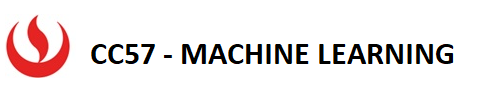

## **ACTIVIDAD #3:** ZOMATO - PLATAFORMA DE RESTAURANTES - CALIDAD DE LOS DATOS

###**1. DESCRIPCION**

**ZOMATO** es conjunto de datos contiene información sobre varios restaurantes que figuran en la plataforma, incluida su ubicación, tipo de cocina, calificaciones, reseñas de usuarios y otros atributos esenciales.
Los datos están diseñados para ayudar a investigadores, entusiastas de los datos y analistas a obtener información sobre la industria de los restaurantes, las preferencias de los clientes y las tendencias culinarias regionales.

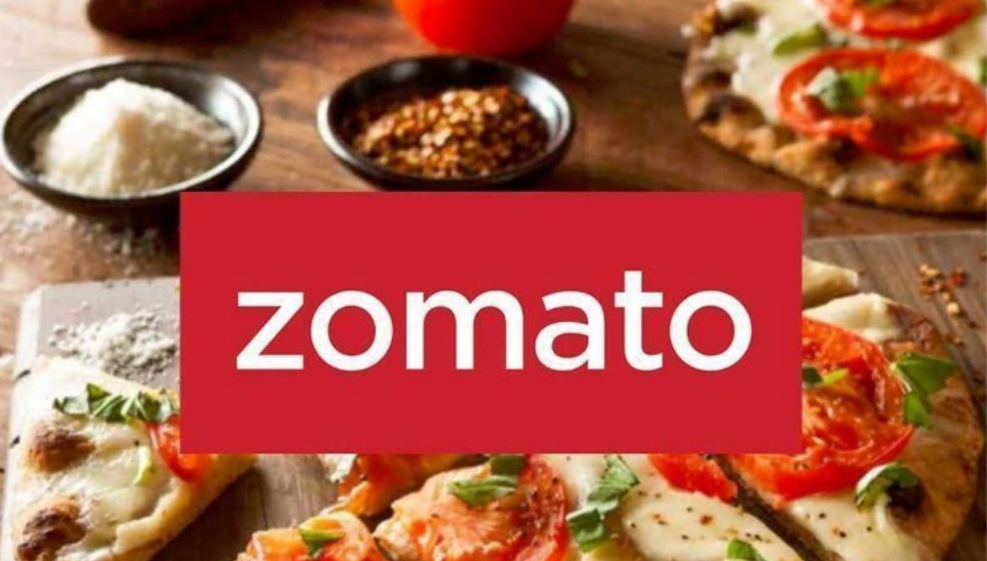

### **2. OBJETIVO**

Realizar:
- Un análisis EDA a partir de los datos proporcionados
- Calcular/visualizar sus principales estadísticas
- Reducir la dimensionalidad del conjunto de datos a 6 componentes (imprima las caracteristicas consideradas en cada uno de los componentes).

####**3. ANALISIS EXPLORATORIO DE LOS DATOS**

El archivo **zomato.csv** es un archivo de valores separados por comas (CSV) que contiene el conjunto de datos del restaurante Zomato. Está diseñado para facilitar el almacenamiento, el intercambio y el análisis de la información relacionada con los restaurantes recopilada desde la plataforma Zomato.

**Conjunto de datos**

El dataset contiene 9551 observaciones en 21 variables.

**Estructura**

- **Restaurant Id :** Unique id of every restaurant across various cities of the world
- **Restaurant Name :** Name of the restaurant
- **Country Code :** Country in which restaurant is located
- **City:** City in which restaurant is located
- **Address:** Address of the restaurant
- **Locality:** Location in the city
- **Locality Verbose:** Detailed description of the locality
- **Longitude:** Longitude coordinate of the restaurant’s location
- **Latitude:** Latitude coordinate of the restaurant’s location
- **Cuisines:** Cuisines offered by the restaurant
- **Average Cost for two:** Cost for two people in different currencies (local currency)
- **Currency:** Currency of the country
- **Has Table booking:** yes/no
- **Has Online delivery:** yes/ no
- **Is delivering:** yes/ no
- **Switch to order menu:** yes/no
- **Price range:** range of price of food
- **Aggregate Rating:** Average rating out of 5
- **Rating color:** depending upon the average rating color
- **Rating text:** text on the basis of rating of rating
- **Votes:** Number of ratings given

**Consideraciones:**

- **Switch to order menu** es NO para todas las observaciones, por lo tanto no tiene valor.
- **Price range ranges** va de uno a cuatro, siendo cuatro restaurantes de precio premium.

Adicionamente se tiene el archivo de paises **Country-Code.csv** a fin de obtener el nombre del pais donde se ubica el resturant.

#### **3.1. Librerias**

In [299]:
#!pip install openpyxl
#!pip install scikit-learn

In [300]:
#Incluya las principales librerias a utilizar
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#### **3.2. Carga de datos**

In [ ]:
df = pd.read_csv('zomato.csv', encoding='latin-1')
# cambiamos el encoding de utf-8 a latin-1 para evitar errores de codificación
country_df = pd.read_excel('Country-Code.xlsx')

####**3.3. Resumen de los datos**


In [302]:
print(df.shape)
print(country_df.shape)

(9551, 21)
(15, 2)


In [303]:
#Info, head y shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [304]:
print(country_df.info())
country_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Code  15 non-null     int64 
 1   Country       15 non-null     object
dtypes: int64(1), object(1)
memory usage: 372.0+ bytes
None


,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [305]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [306]:
df['Country Code'].unique().__len__()

15

In [307]:
#Incluir el país en conjunto de datos
df = pd.merge(df, country_df, on='Country Code', how='left') #
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [308]:
df['Country'].unique().__len__()

15

In [309]:
# Mostrar detalles estadísticos básicos (solo los calcula a las variables numericas)
df.describe()


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [310]:
# Verificar data faltante en cada columna y duplicados
print(df.isnull().sum())
print(df.duplicated().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64
0


In [311]:
print(df['Restaurant ID'].duplicated().sum())

0


In [312]:
#Verificar proporciones de valores nulos
(df.isnull().mean() * 100).round(2)

Restaurant ID           0.00
Restaurant Name         0.00
Country Code            0.00
City                    0.00
Address                 0.00
Locality                0.00
Locality Verbose        0.00
Longitude               0.00
Latitude                0.00
Cuisines                0.09
Average Cost for two    0.00
Currency                0.00
Has Table booking       0.00
Has Online delivery     0.00
Is delivering now       0.00
Switch to order menu    0.00
Price range             0.00
Aggregate rating        0.00
Rating color            0.00
Rating text             0.00
Votes                   0.00
Country                 0.00
dtype: float64

In [313]:
#Verificar duplicación de registros u observaciones
# no tenemos duplciados, pero daremos un revisado rapido a los missing values
#df[df['Cuisines'].isnull() == True]
#df[df['Cuisines'].isnull() == True].describe()
# No encotramos un patron claro
print(f'Percent mv Cuisines: {(df["Cuisines"].isnull().mean()*100).__round__(2)}%') 

Percent mv Cuisines: 0.09%


In [314]:
# ver cuantos 0 hay en votes
print(f'Percent 0 votes: {(df["Votes"] == 0).mean()*100} %')
# ver cuantos 0 hay en Aggregrate rating
print(f'Percent 0 rating: {(df["Aggregate rating"] == 0).mean()*100} %')
# ver cuantos 0 hay en Price range
print(f'Percent 0 price range: {(df["Price range"] == 0).mean()*100} %')
# ver cuantos 0 hay en Average cost for two
print(f'Percent 0 average cost: {(df["Average Cost for two"] == 0).mean()*100} %')

Percent 0 votes: 11.454297979269185 %
Percent 0 rating: 22.489791644853945 %
Percent 0 price range: 0.0 %
Percent 0 average cost: 0.18846194115799395 %


###**3.4. Preprocesamiento de los datos**

In [315]:
#Como solucionamos los datos faltantes? Eliminamos todos los datos faltantes?
#Utilice una tecnica para reemplazar los datos faltantes (una para valores numericos y otra para categoricos)
# Reemplazar valores 0 en 'Votes' y 'Aggregate rating' por NaN para luego usar la mediana, por estos outliers
df['Votes'] = df['Votes'].replace(0, np.nan)  
df['Aggregate rating'] = df['Aggregate rating'].replace(0, np.nan)
df['Average Cost for two'] = df['Average Cost for two'].replace(0, np.nan)

# Imputar valores numéricos con la mediana
df['Votes'] = df['Votes'].fillna(df['Votes'].median())
df['Aggregate rating'] = df['Aggregate rating'].fillna(df['Aggregate rating'].median())
df['Average Cost for two'] = df['Average Cost for two'].fillna(df['Average Cost for two'].median())

# son poquitos y sin ningun patron aparentemente relevante 
# Imputar valores categóricos con la moda
df['Cuisines'] = df['Cuisines'].fillna(df['Cuisines'].mode()[0])

Valores faltantes en alguna columna: 0


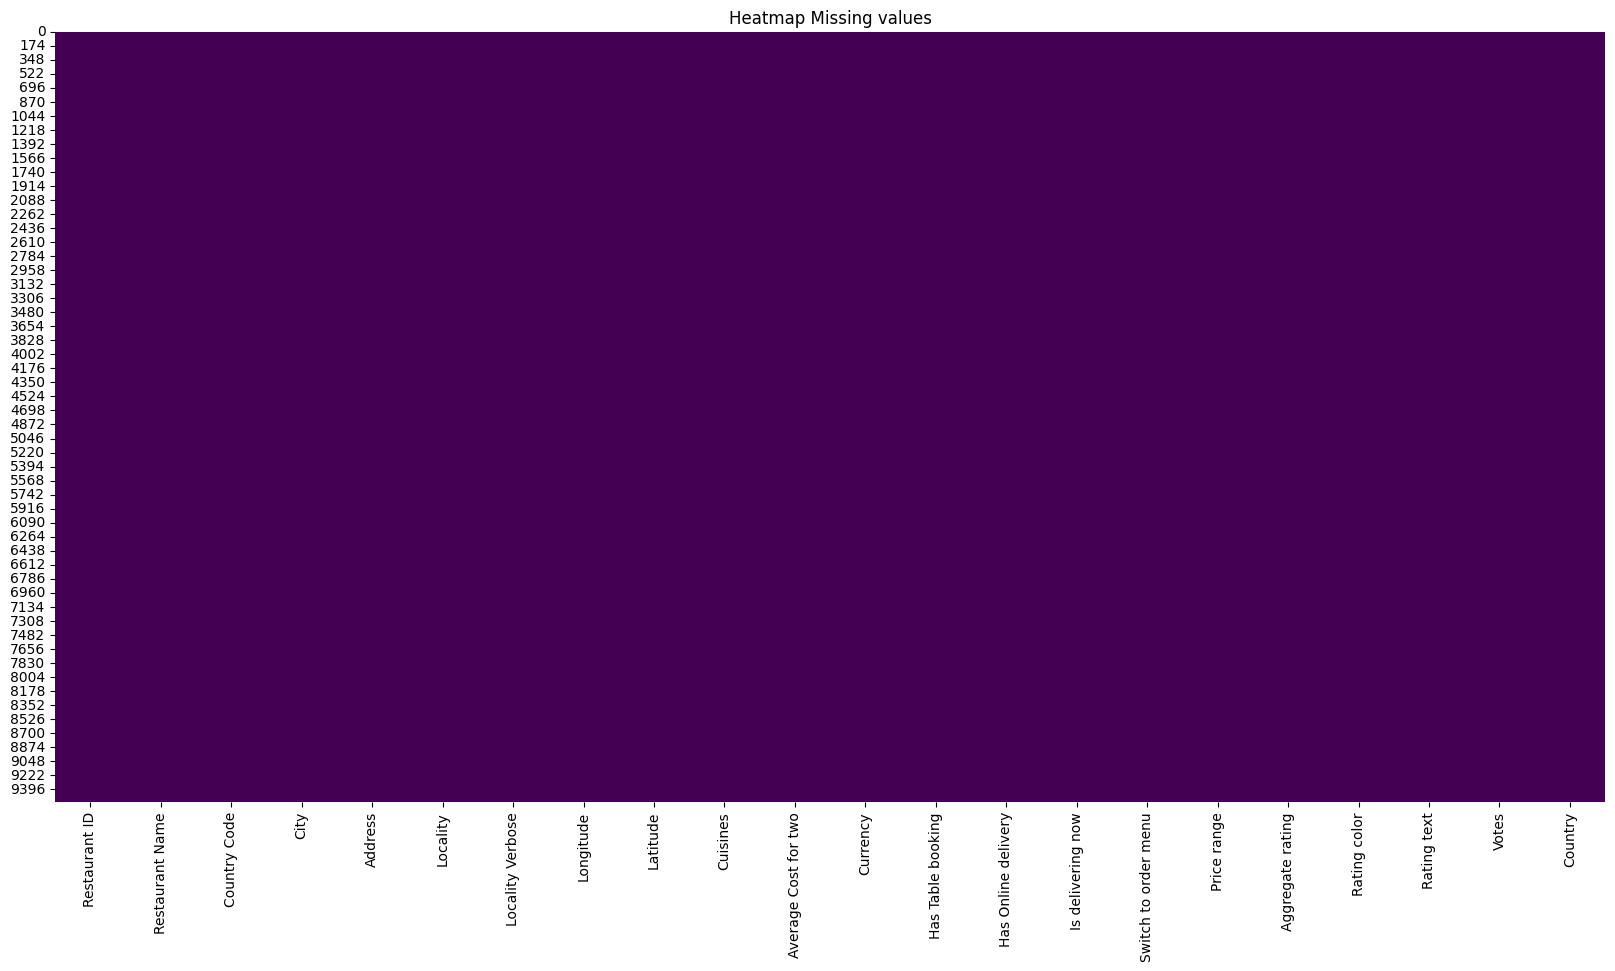

In [316]:
#Verificamos que no existan datos faltantes

print(f'Valores faltantes en alguna columna: {df.isnull().sum().sum()}')

plt.figure(figsize=(20, 10))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap Missing values')
plt.show()

Columnas duplicadas 0


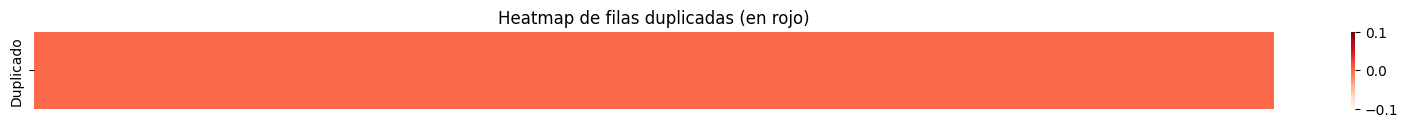

In [317]:
#Solucionar duplicidad en los datos (si existen)
# No hace falta

print(f'Columnas duplicadas {df.duplicated().sum()}')

df_aux = df.copy()
df_aux['Duplicado'] = df_aux.duplicated()
plt.figure(figsize=(20, 1))
sns.heatmap([df_aux['Duplicado']], cmap='Reds', cbar=True, xticklabels=False)
plt.title('Heatmap de filas duplicadas (en rojo)')
plt.yticks([0.5], ['Duplicado'])
plt.show()


<Figure size 2000x1000 with 0 Axes>

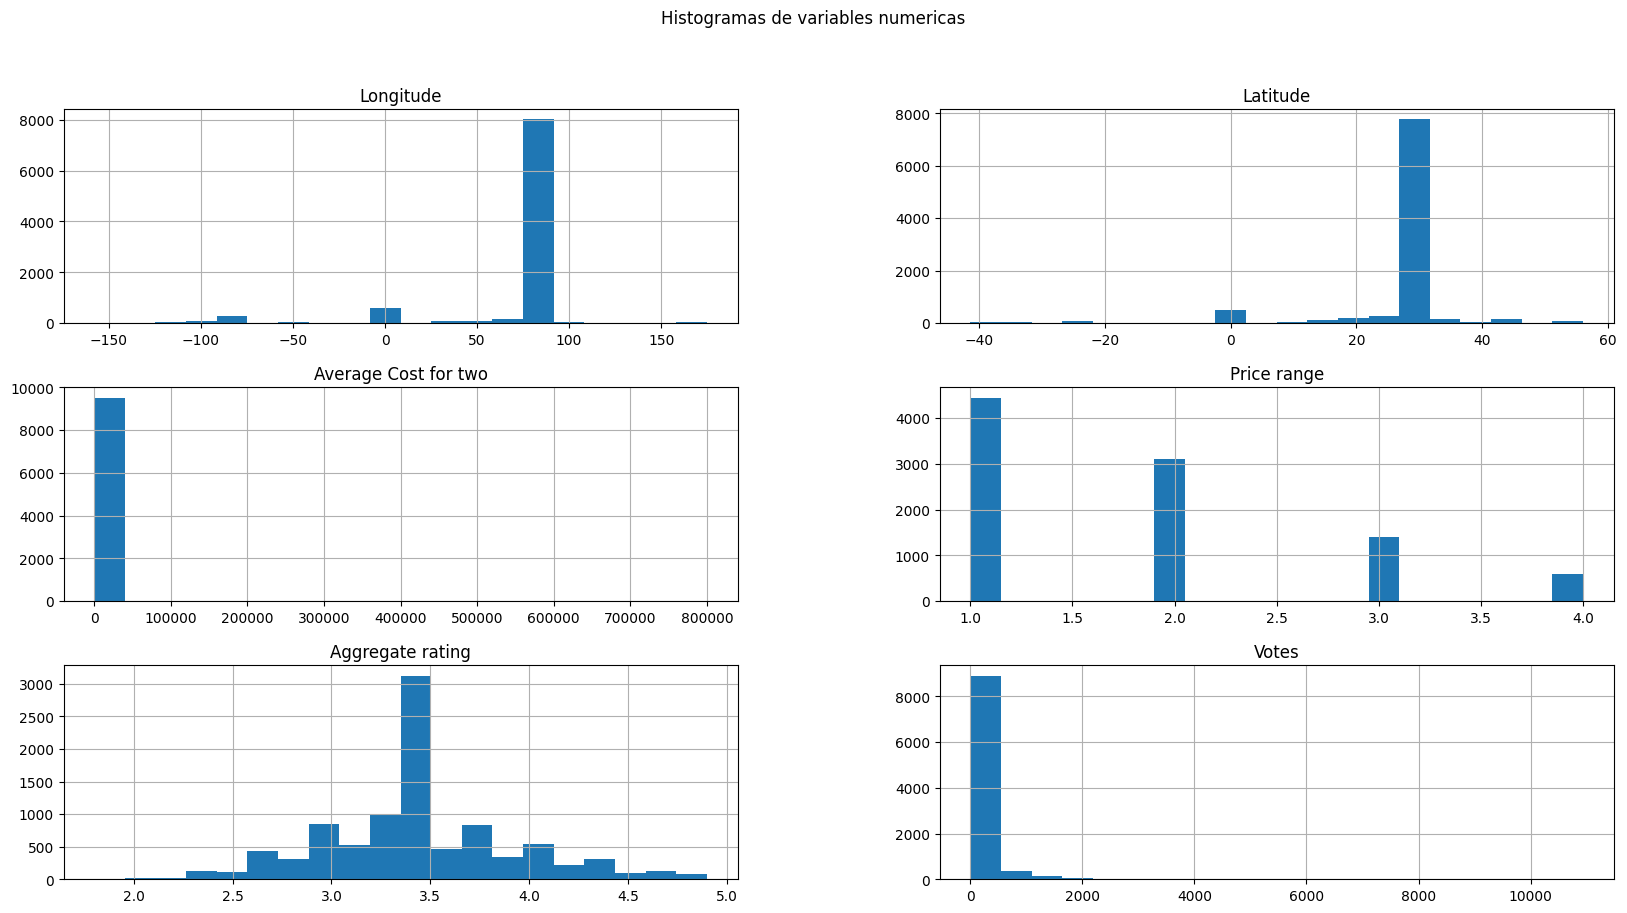

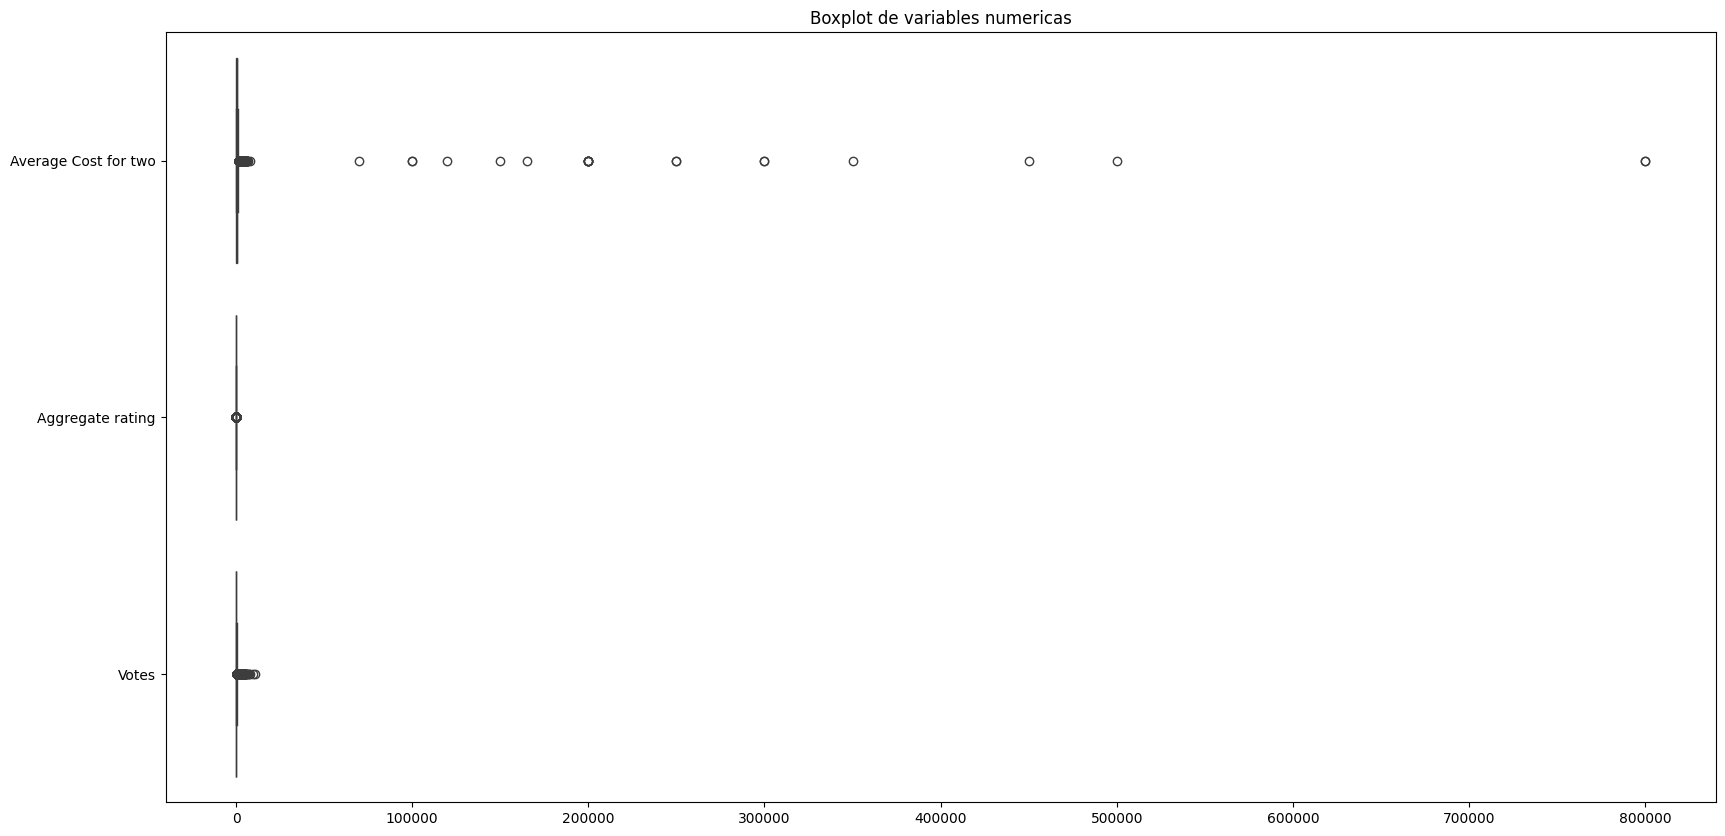

In [318]:
#Identificar variables con valores atipicos
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns.remove('Restaurant ID')
numeric_columns.remove('Country Code')
# Graficar histogramas de las variables numericas
plt.figure(figsize=(20, 10))
df[numeric_columns].hist(bins=20, figsize=(20, 10))
plt.suptitle('Histogramas de variables numericas')
plt.show()

# Graficar boxplot de las variables numericas
plt.figure(figsize=(20, 10))
sns.boxplot(data=df[['Average Cost for two', 'Aggregate rating', 'Votes']], orient='h')
plt.title('Boxplot de variables numericas')
plt.show()


In [319]:
df['Country'].unique().__len__()

15

In [320]:
# De existir, eliminar Outliers describiendo que tecnica(s) ha utilizado en cada caso
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Aplicar la función a las columnas numéricas

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns.remove('Restaurant ID')
numeric_columns.remove('Country Code')
numeric_columns.remove('Longitude')
numeric_columns.remove('Latitude')

numeric_columns

['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']

Valores atipicos eliminados de Average Cost for two
Valores restantes: 8698
Valores atipicos eliminados: 0
Valores atipicos eliminados de Price range
Valores restantes: 8496
Valores atipicos eliminados: 0
Valores atipicos eliminados de Aggregate rating
Valores restantes: 8122
Valores atipicos eliminados: 0
Valores atipicos eliminados de Votes
Valores restantes: 7196
Valores atipicos eliminados: 0
Valores restantes: 7196 de 9551 registros


<Figure size 2000x1000 with 0 Axes>

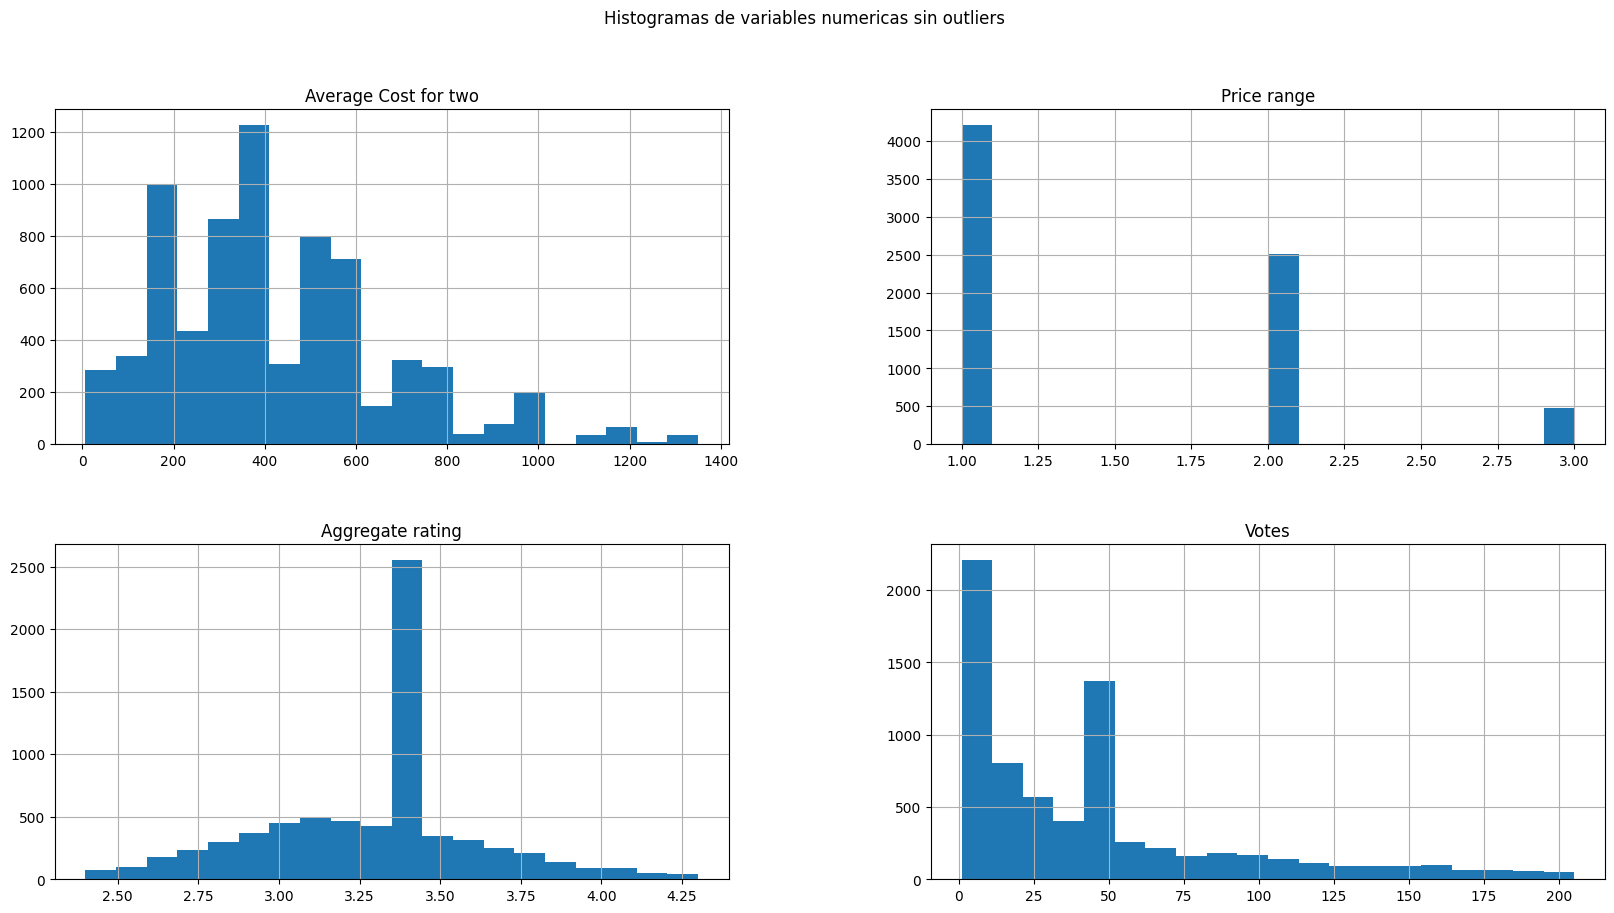

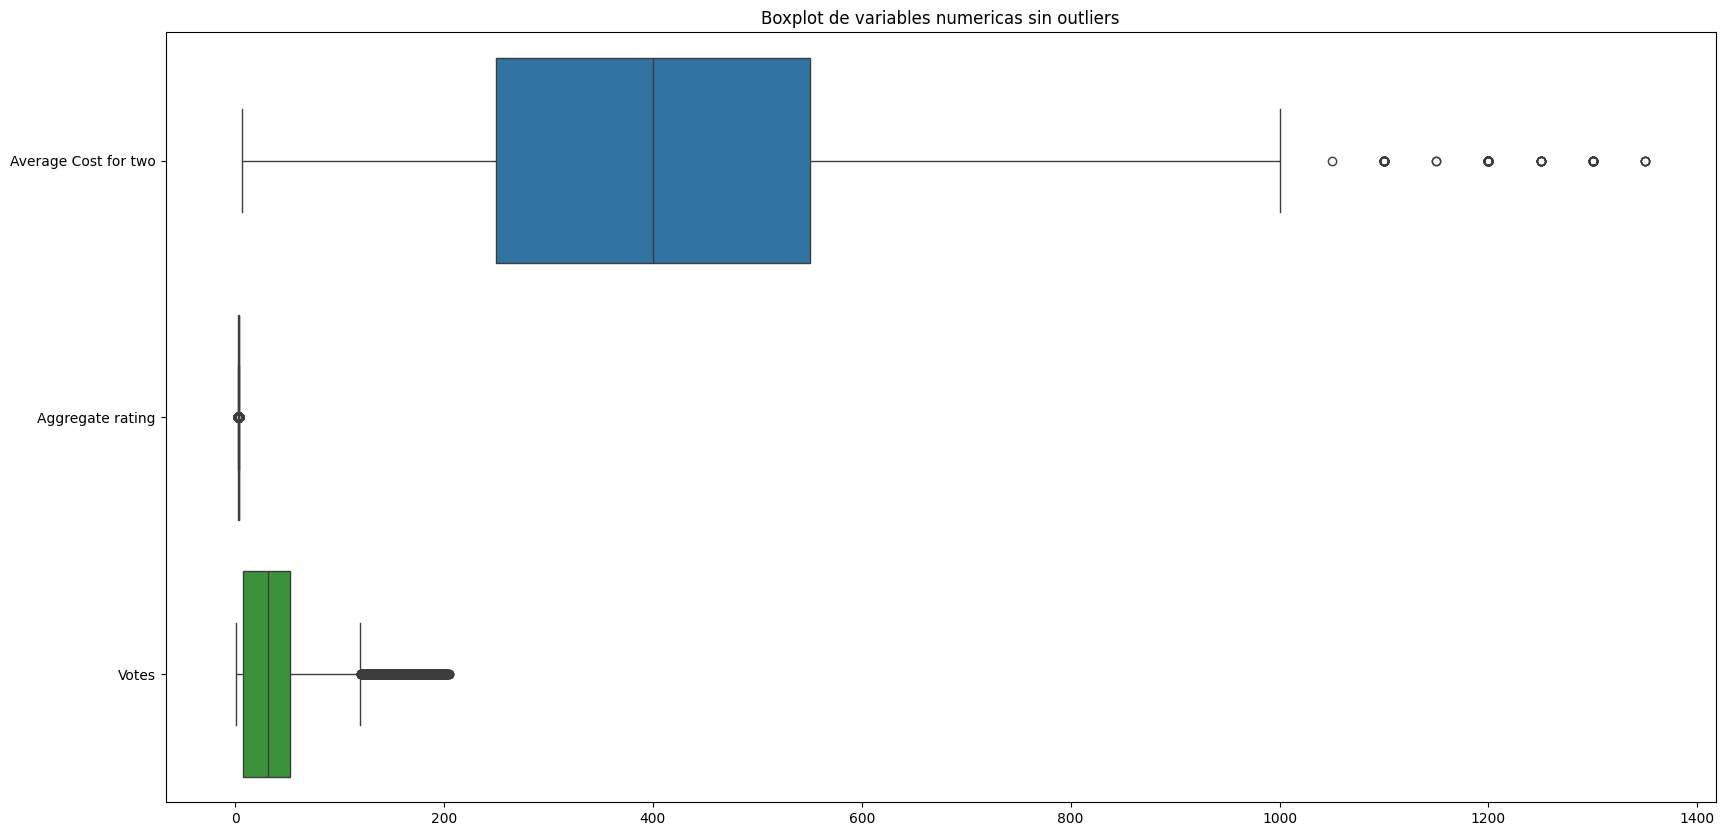

In [321]:


n = df.shape[0]
for column in numeric_columns:
    df = remove_outliers_iqr(df, column)
    n_out_delete = df[column].shape[0] - df[column].dropna().shape[0]
    print(f'Valores atipicos eliminados de {column}')
    print(f'Valores restantes: {df[column].shape[0]}')
    print(f'Valores atipicos eliminados: {n_out_delete}')
print(f'Valores restantes: {df.shape[0]} de {n} registros')
# Verificar si se han eliminado los outliers
plt.figure(figsize=(20, 10))
df[numeric_columns].hist(bins=20, figsize=(20, 10))
plt.suptitle('Histogramas de variables numericas sin outliers')
plt.show()
# Graficar boxplot de las variables numericas sin outliers
plt.figure(figsize=(20, 10))
sns.boxplot(data=df[['Average Cost for two', 'Aggregate rating', 'Votes']], orient='h')
plt.title('Boxplot de variables numericas sin outliers')
plt.show()


In [322]:
# Genere un dataset con los datos preparados
df.to_csv('zomato_cleaned.csv', index=False)
# Cargamos el dataset limpio
df_cleaned = pd.read_csv('zomato_cleaned.csv')


In [323]:
df['Country'].unique().__len__()


14

A partir de los datos preparados, trabaje las siguientes secciones.

####**4. ESTADISTICA DESCRIPTIVA**

In [324]:
# A partir del dataset preparado, mostrar detalles estadísticos básicos
print(df_cleaned.shape)
print(df_cleaned.info())


(7196, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7196 entries, 0 to 7195
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         7196 non-null   int64  
 1   Restaurant Name       7196 non-null   object 
 2   Country Code          7196 non-null   int64  
 3   City                  7196 non-null   object 
 4   Address               7196 non-null   object 
 5   Locality              7196 non-null   object 
 6   Locality Verbose      7196 non-null   object 
 7   Longitude             7196 non-null   float64
 8   Latitude              7196 non-null   float64
 9   Cuisines              7196 non-null   object 
 10  Average Cost for two  7196 non-null   float64
 11  Currency              7196 non-null   object 
 12  Has Table booking     7196 non-null   object 
 13  Has Online delivery   7196 non-null   object 
 14  Is delivering now     7196 non-null   object 
 15  Switch to 

In [325]:
df_cleaned.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,7.196000e+03,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000
mean,9.837790e+06,8.550167,67.615538,26.489555,424.059477,1.482212,3.292496,43.262646
std,8.921985e+06,38.858727,33.159969,9.133891,248.259183,0.619435,0.353286,45.630732
min,9.300000e+01,1.000000,-124.175346,-41.330428,7.000000,1.000000,2.400000,1.000000
25%,3.037605e+05,1.000000,77.093256,28.505132,250.000000,1.000000,3.100000,8.000000
50%,1.769691e+07,1.000000,77.194391,28.576465,400.000000,1.000000,3.400000,32.000000
75%,1.837789e+07,1.000000,77.286090,28.644836,550.000000,2.000000,3.400000,53.000000
max,1.850065e+07,216.000000,174.793257,55.954040,1350.000000,3.000000,4.300000,205.000000


In [326]:
#Identificar y separar variables numéricas y categóricas

numeric_columns = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df_cleaned.select_dtypes(include=[object]).columns.tolist()

if (len(numeric_columns) + len(categorical_columns)) == df_cleaned.shape[1]:
    print('Las columnas han sido separadas correctamente')

Las columnas han sido separadas correctamente


####**4.1 Análisis Univariado de los Datos**

#### **Diagramas de pares y diagramas de distribución**

In [327]:
# Generar estadísticas descriptivas para columnas numéricas
numeric_columns.remove('Restaurant ID')
numeric_columns.remove('Country Code')
df_cleaned[numeric_columns].describe()

,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000
mean,67.615538,26.489555,424.059477,1.482212,3.292496,43.262646
std,33.159969,9.133891,248.259183,0.619435,0.353286,45.630732
min,-124.175346,-41.330428,7.000000,1.000000,2.400000,1.000000
25%,77.093256,28.505132,250.000000,1.000000,3.100000,8.000000
50%,77.194391,28.576465,400.000000,1.000000,3.400000,32.000000
75%,77.286090,28.644836,550.000000,2.000000,3.400000,53.000000
max,174.793257,55.954040,1350.000000,3.000000,4.300000,205.000000


In [328]:
# Generar estadísticas descriptivas para columnas categóricas
# Si No hay variables categoricas, considere crear algunas
df_cleaned[categorical_columns].describe()


,Restaurant Name,City,Address,Locality,Locality Verbose,Cuisines,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Rating color,Rating text,Country
count,7196,7196,7196,7196,7196,7196,7196,7196,7196,7196,7196,7196,7196,7196
unique,5630,100,6815,675,721,1008,11,2,2,2,1,5,5,14
top,Cafe Coffee Day,New Delhi,"Sector 41, Noida",Shahdara,"Shahdara, New Delhi",North Indian,Indian Rupees(Rs.),No,No,No,No,Orange,Average,India
freq,80,4554,11,87,87,876,6900,6828,5473,7170,7196,3440,3440,6900


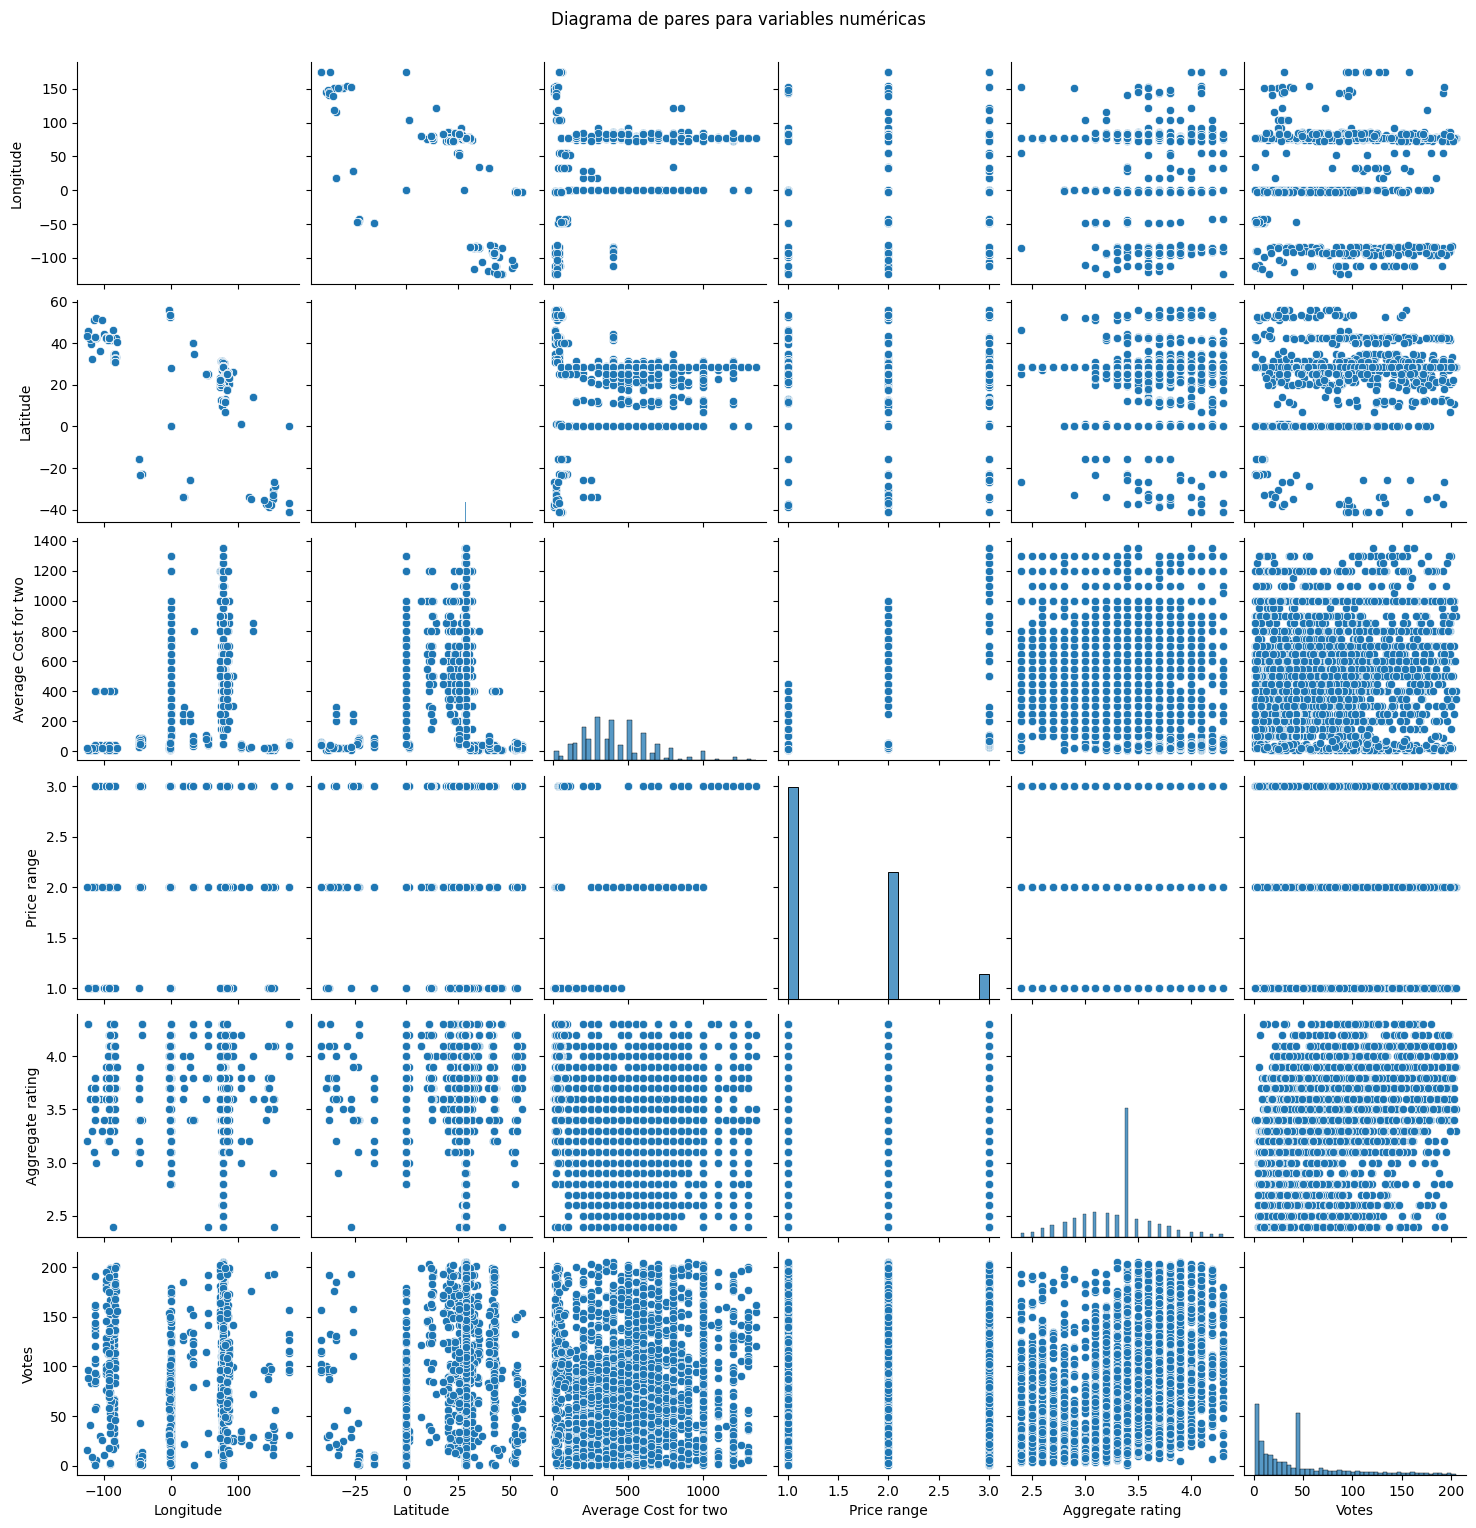

In [329]:
# Utilice algunas de las medidas de dispersion y representelas a traves de diagramas
# Creando un diagrama de pares y de distribucion para variables numéricas
sns.pairplot(df_cleaned[numeric_columns])
plt.suptitle('Diagrama de pares para variables numéricas', y=1.02)
plt.show()

####**4.2 Análisis Bivariado de los Datos**

#### **- Correlacion de variables**

In [330]:
# Calcular e imprimir la matriz de correlación para variables numéricas.

correlation_matrix = df_cleaned[numeric_columns].corr()
correlation_matrix

,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
Longitude,1.000000,0.215618,0.217420,-0.070913,-0.213760,-0.139647
Latitude,0.215618,1.000000,-0.016438,-0.056364,-0.104124,0.026004
Average Cost for two,0.217420,-0.016438,1.000000,0.737508,-0.045693,0.234577
Price range,-0.070913,-0.056364,0.737508,1.000000,0.110407,0.341698
Aggregate rating,-0.213760,-0.104124,-0.045693,0.110407,1.000000,0.383422
Votes,-0.139647,0.026004,0.234577,0.341698,0.383422,1.000000


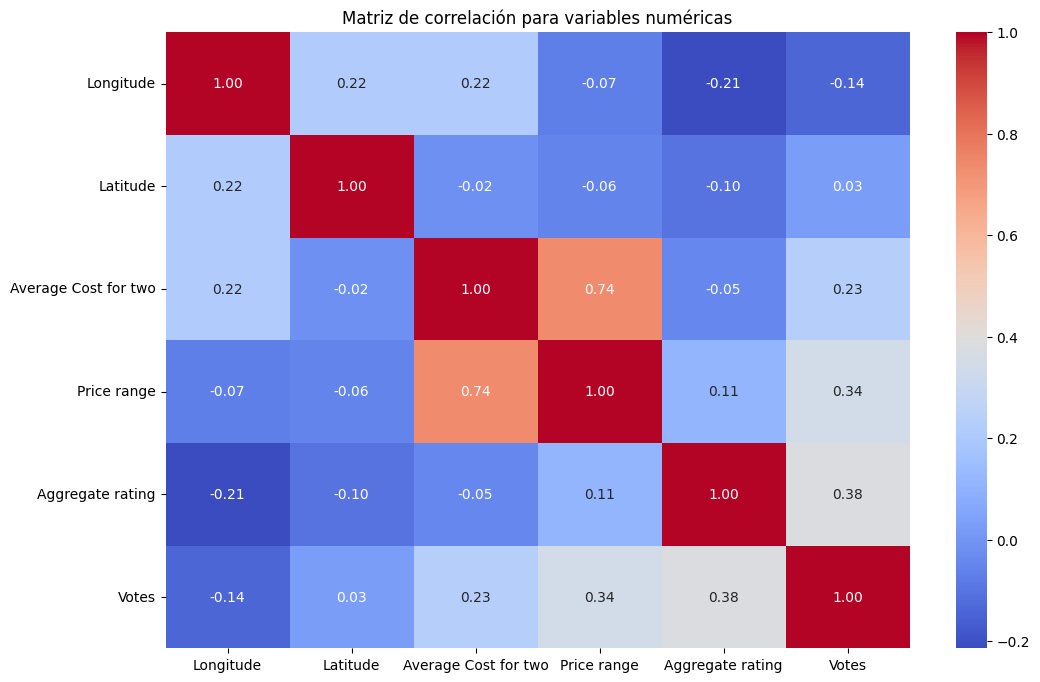

In [331]:
# Visualizar la matriz de correlacion en un mapa de calor

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación para variables numéricas')
plt.show()

¿Qué variables son las tienen mayor correlación?

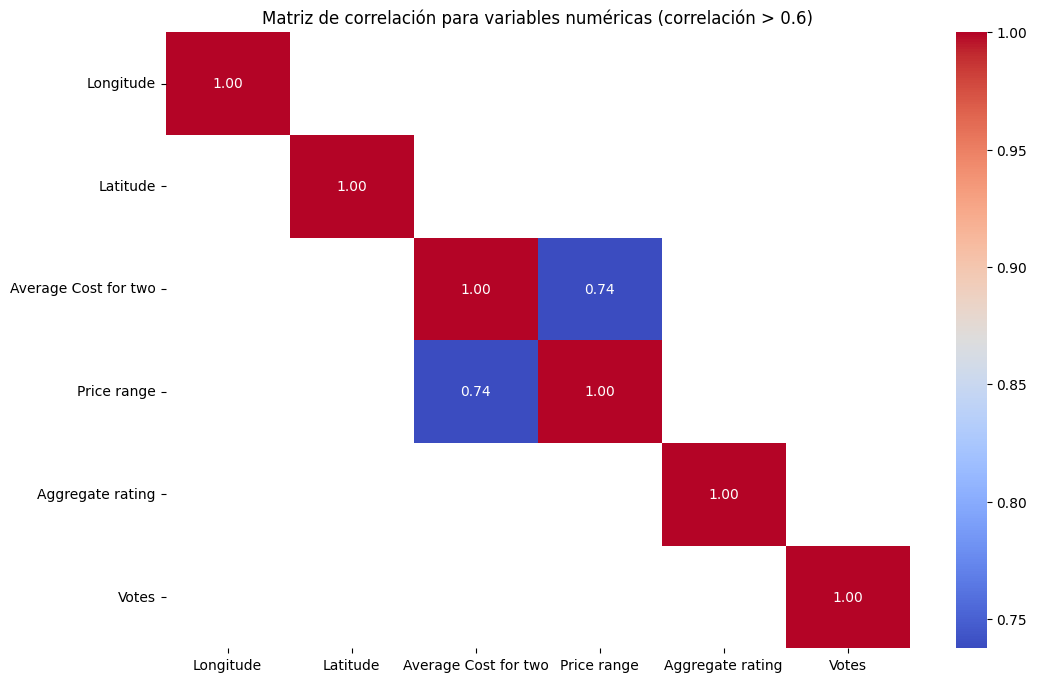

In [332]:
#Identifique las variables numericas que guardan una correlacion superior a 0.6
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix[correlation_matrix > 0.6], annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación para variables numéricas (correlación > 0.6)')
plt.show()

**Respuesta:**

### **5. Visualización de los datos**

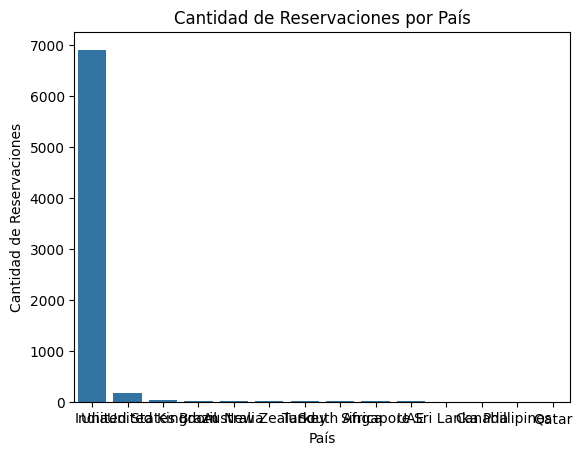

In [333]:
#Grafico de barras descendente de paises que componen el dataset totalizando por cntidada de reservaciones
sns.countplot(data=df_cleaned, x='Country', order=df_cleaned['Country'].value_counts().index)
plt.title('Cantidad de Reservaciones por País')
plt.xlabel('País')
plt.ylabel('Cantidad de Reservaciones')
plt.show()


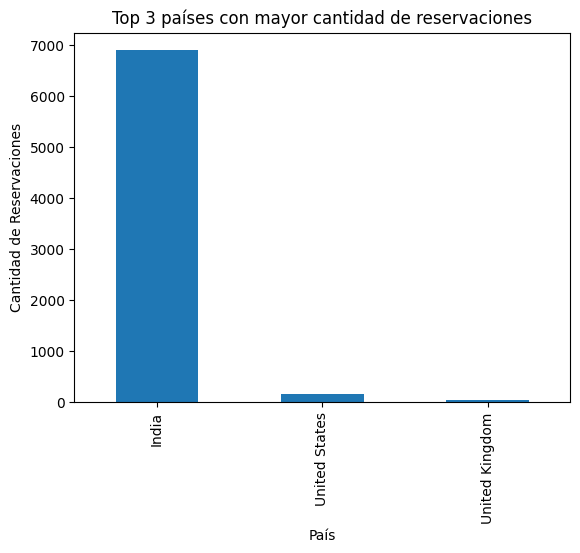

In [334]:
#Visualizar los 3 paises top con mayor cantidad de reservaciones (seniale que pais recibe la mayor cantidad de reservas).
# Grafico de barras o pie
top_countries = df_cleaned['Country'].value_counts().head(3)#xd
top_countries.plot(kind='bar')
plt.title('Top 3 países con mayor cantidad de reservaciones')
plt.xlabel('País')
plt.ylabel('Cantidad de Reservaciones')
plt.show()

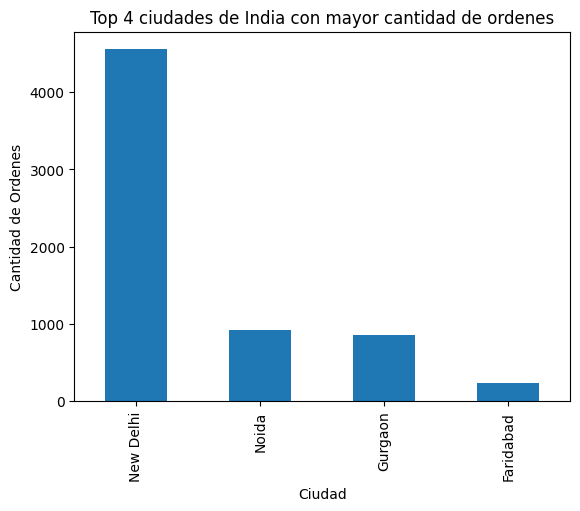

In [335]:
# Top 4 ciudades del pais con mayor cantidad de ordenes (identifique cual es la ciudad con el mayor numero de ordenes)
# Grafico de barras o pie
top_country = df_cleaned['Country'].value_counts().idxmax()
top_cities = df_cleaned[df_cleaned['Country'] == top_country]['City'].value_counts().head(4)
top_cities.plot(kind='bar')
plt.title(f'Top 4 ciudades de {top_country} con mayor cantidad de ordenes')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de Ordenes')
plt.show()

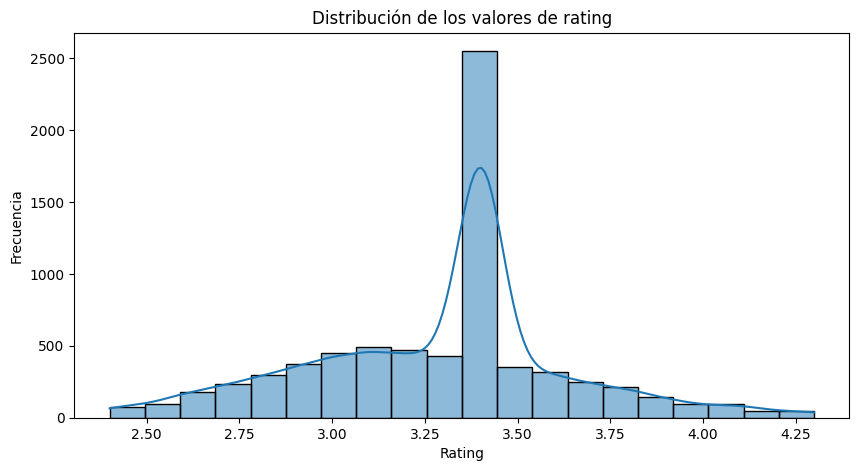

In [336]:
# Visualizar como es la distribucion de los valores de rating en general

plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['Aggregate rating'], bins=20, kde=True)
plt.title('Distribución de los valores de rating')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()


/tmp/ipykernel_66751/1548601245.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')


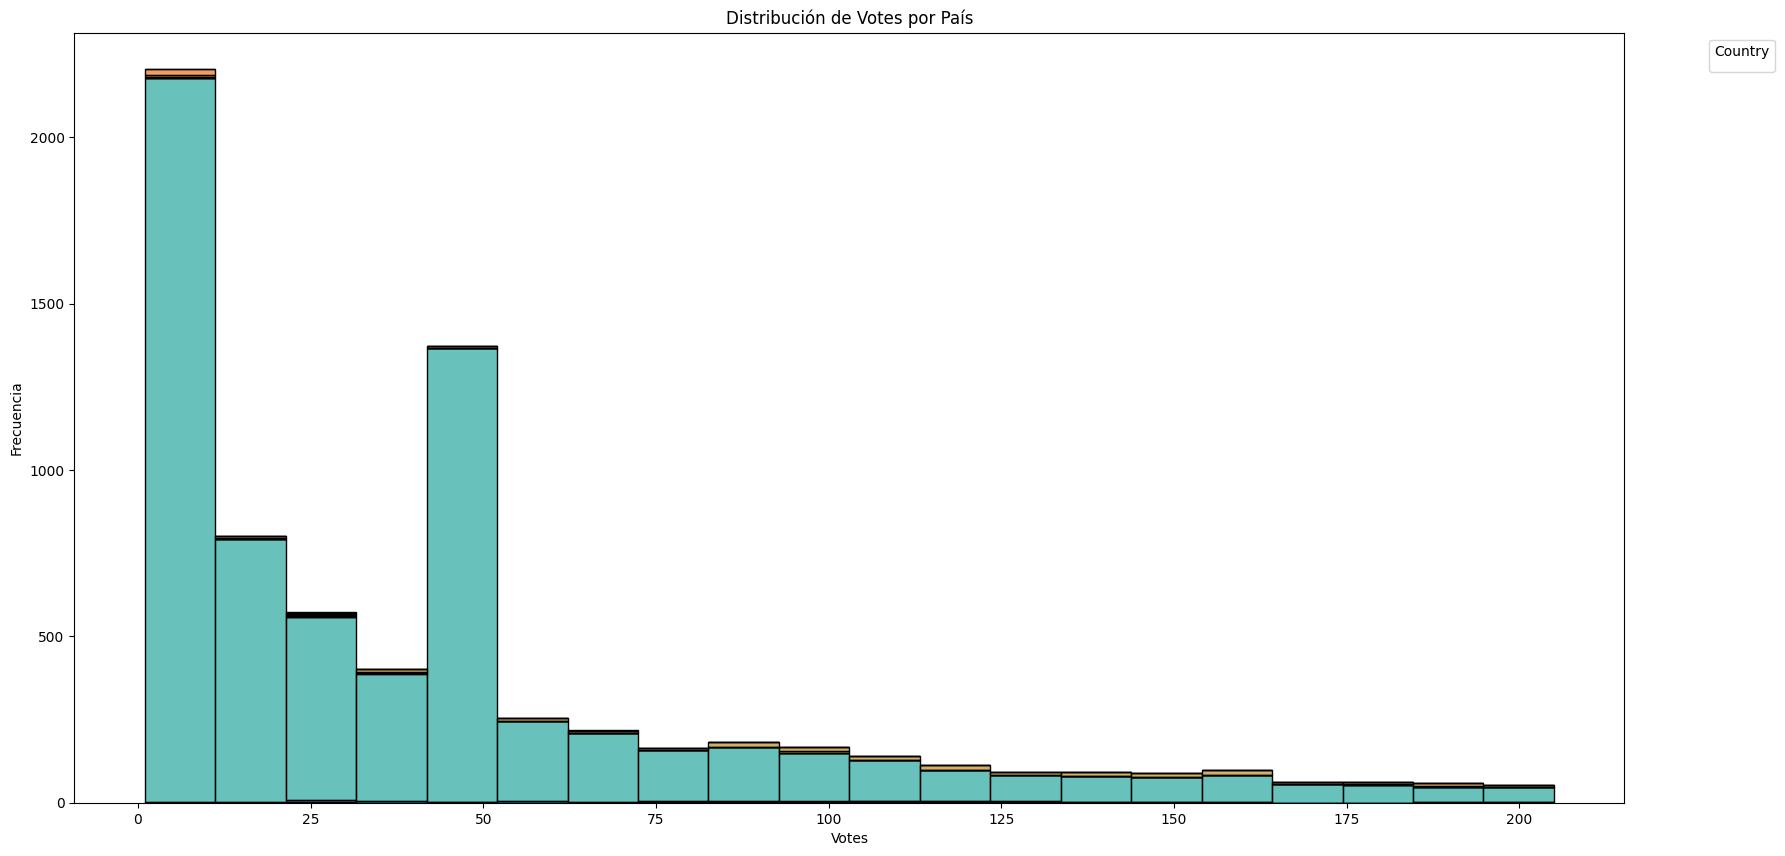

In [337]:
#Distribucion de votes por cada pais
plt.figure(figsize=(20, 10))
sns.histplot(data=df_cleaned, x='Votes', hue='Country', multiple='stack', bins=20)
plt.title('Distribución de Votes por País')
plt.xlabel('Votes')
plt.ylabel('Frecuencia')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/tmp/ipykernel_66751/2789801709.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')


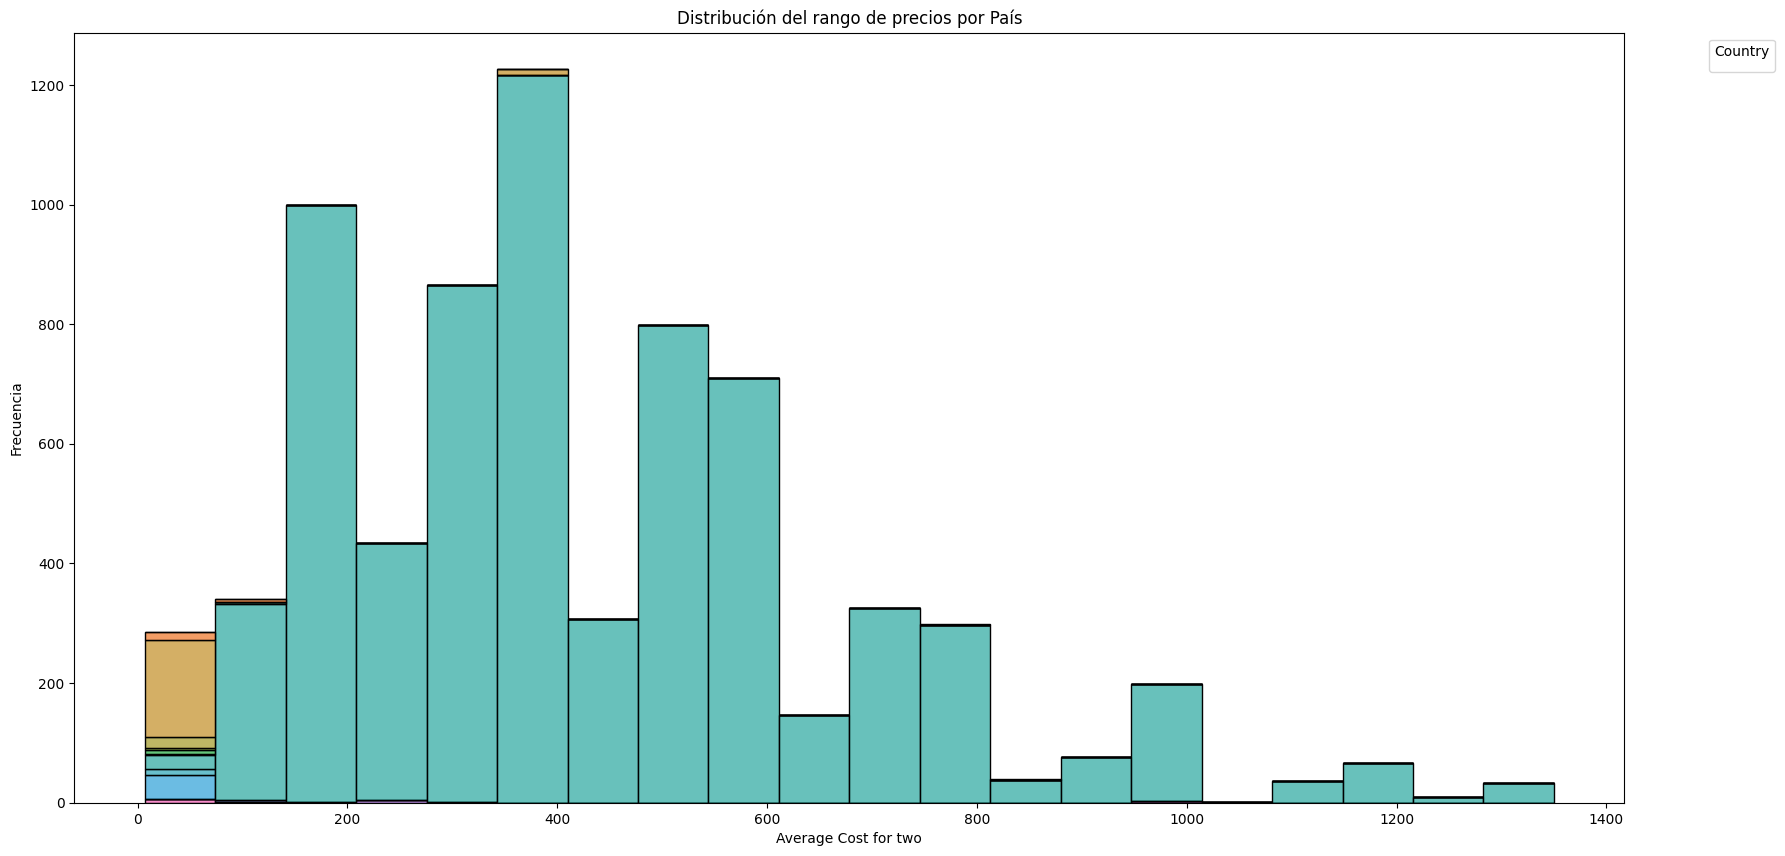

In [338]:
#Distribucion del rango de precios
plt.figure(figsize=(20, 10))
sns.histplot(data=df_cleaned, x='Average Cost for two', hue='Country', multiple='stack', bins=20)
plt.title('Distribución del rango de precios por País')
plt.xlabel('Average Cost for two')
plt.ylabel('Frecuencia')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **6. Transformacion:** Reduccion de Dimensionalidad


In [339]:
#Aplicación del Análisis de Componentes Principales (PCA) con 2 componentes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Definir las columnas numéricas para PCA
numeric_columns = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

numeric_columns.remove('Restaurant ID')
numeric_columns.remove('Country Code')


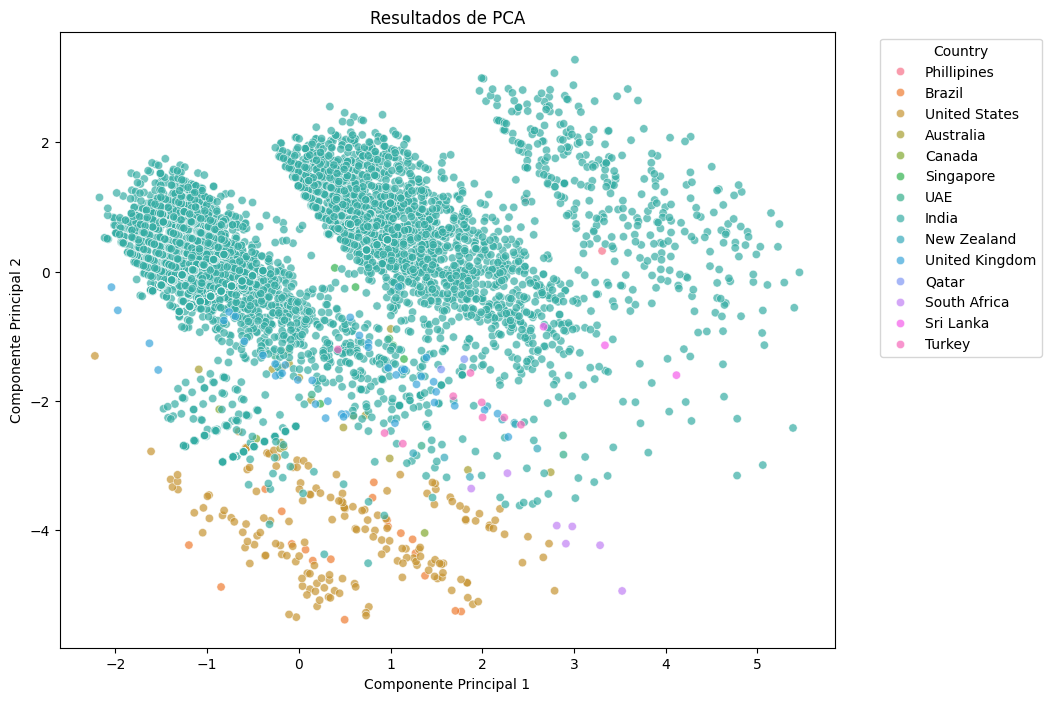

In [ ]:

# Definir el preprocesador para escalar los datos
preprocessor = ColumnTransformer( 
    transformers=[
        ('num', StandardScaler(), numeric_columns)
    ]
)
# Crear el pipeline para PCA
pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=2))
])
# Ajustar el pipeline a los datos
pca_pipeline.fit(df_cleaned[numeric_columns])
# Transformar los datos
pca_result = pca_pipeline.transform(df_cleaned[numeric_columns])
# Crear un DataFrame con los resultados de PCA
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
# Agregar la variable objetivo al DataFrame
pca_df['Country'] = df_cleaned['Country'].values
# Graficar los resultados de PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Country', alpha=0.7)
plt.title('Resultados de PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [341]:
#Imprima las 4 caracteristicas mas importantes de cada componente

pca = PCA(n_components=2)
pca.fit(df_cleaned[numeric_columns])
# Obtener la matriz de carga
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
# Crear un DataFrame con las cargas
loadings_df = pd.DataFrame(loadings, index=numeric_columns, columns=['PC1', 'PC2'])
loadings_df = loadings_df.abs()
loadings_df = loadings_df.sort_values(by='PC1', ascending=False)
loadings_df

,PC1,PC2
Average Cost for two,248.251122,1.558109
Votes,11.020422,43.432686
Longitude,7.281192,12.624482
Price range,0.457116,0.127551
Latitude,0.140289,0.150516
Aggregate rating,0.015290,0.149585


In [345]:
# Obtener las 4 características más importantes de cada componente
top_features_pc1 = loadings_df['PC1'].abs().nlargest(4).index.tolist()
top_features_pc2 = loadings_df['PC2'].abs().nlargest(4).index.tolist()
print('Top 4 características más importantes de PC1:\n')
for feature in top_features_pc1:
    print(feature)
print('\nTop 4 características más importantes de PC2:\n')
for feature in top_features_pc2:
    print(feature)

Top 4 características más importantes de PC1:

Average Cost for two
Votes
Longitude
Price range

Top 4 características más importantes de PC2:

Votes
Longitude
Average Cost for two
Latitude


### **7. Observaciones**

**Respuesta:** (liste las principales observaciones o conclusiones observadas luego del análisis)

Es importante revisar que valores puedan establecerse por defecto en caso de valores nulos al limpiar la data

PCA nos permite representar datos n-dimensionales para poder comprenderlos visualmente 